In [1]:
import pandas as pd

file_path = r"D:\MScProjects\labour-market-intelligence\data\processed\digital_demand_2023_2025.csv"

df = pd.read_csv(file_path)

df["Month"] = pd.to_datetime(df["Month"])

df.head()

,Month,2134 Programmers and software development professionals,2135 Cyber security professionals,"2433 Actuaries, economists and statisticians",3133 Database administrators and web content technicians,3544 Data analysts
0,2023-01-01,25269.0,3712.0,3993.0,2397.0,3606.0
1,2023-02-01,25118.0,3367.0,3131.0,2084.0,3358.0
2,2023-03-01,21905.0,3073.0,2908.0,1883.0,3261.0
3,2023-04-01,15409.0,2511.0,2473.0,1507.0,2462.0
4,2023-05-01,17787.0,2923.0,3069.0,1958.0,2962.0


In [2]:
print(df.shape)
print(df["Month"].min())
print(df["Month"].max())

(29, 6)
2023-01-01 00:00:00
2025-05-01 00:00:00


In [3]:
# Create Year and Month columns

df["Year"] = df["Month"].dt.year
df["Month_Name"] = df["Month"].dt.strftime("%b")

df.head()

,Month,2134 Programmers and software development professionals,2135 Cyber security professionals,"2433 Actuaries, economists and statisticians",3133 Database administrators and web content technicians,3544 Data analysts,Year,Month_Name
0,2023-01-01,25269.0,3712.0,3993.0,2397.0,3606.0,2023,Jan
1,2023-02-01,25118.0,3367.0,3131.0,2084.0,3358.0,2023,Feb
2,2023-03-01,21905.0,3073.0,2908.0,1883.0,3261.0,2023,Mar
3,2023-04-01,15409.0,2511.0,2473.0,1507.0,2462.0,2023,Apr
4,2023-05-01,17787.0,2923.0,3069.0,1958.0,2962.0,2023,May


In [4]:
yearly_avg = df.groupby("Year").mean(numeric_only=True)

yearly_avg

,2134 Programmers and software development professionals,2135 Cyber security professionals,"2433 Actuaries, economists and statisticians",3133 Database administrators and web content technicians,3544 Data analysts
Year,,,,,
2023,16183.750000,2457.750000,2449.750000,1592.250000,2466.583333
2024,8247.416667,1428.583333,1543.416667,1111.166667,1459.666667
2025,9306.800000,1836.800000,1949.000000,1151.200000,1616.800000


In [5]:
yearly_avg.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\yearly_average_demand.csv"
)

yearly_avg

,2134 Programmers and software development professionals,2135 Cyber security professionals,"2433 Actuaries, economists and statisticians",3133 Database administrators and web content technicians,3544 Data analysts
Year,,,,,
2023,16183.750000,2457.750000,2449.750000,1592.250000,2466.583333
2024,8247.416667,1428.583333,1543.416667,1111.166667,1459.666667
2025,9306.800000,1836.800000,1949.000000,1151.200000,1616.800000


Matplotlib is building the font cache; this may take a moment.


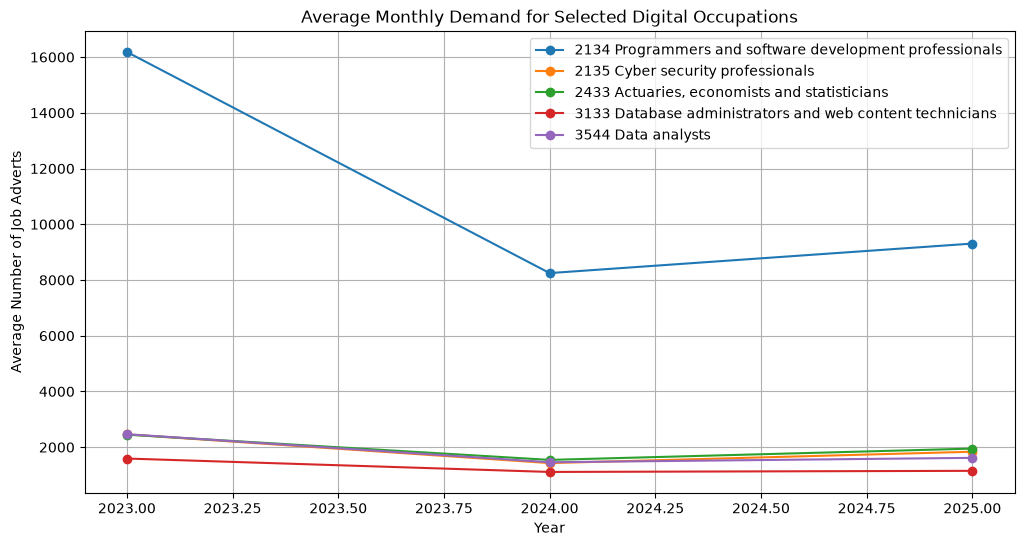

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for column in yearly_avg.columns:
    plt.plot(yearly_avg.index,
             yearly_avg[column],
             marker='o',
             label=column)

plt.title("Average Monthly Demand for Selected Digital Occupations")
plt.xlabel("Year")
plt.ylabel("Average Number of Job Adverts")
plt.legend()

plt.grid(True)

plt.show()

In [7]:
growth = yearly_avg.pct_change()*100

growth.round(2)

,2134 Programmers and software development professionals,2135 Cyber security professionals,"2433 Actuaries, economists and statisticians",3133 Database administrators and web content technicians,3544 Data analysts
Year,,,,,
2023,NaN,NaN,NaN,NaN,NaN
2024,-49.04,-41.87,-37.00,-30.21,-40.82
2025,12.85,28.57,26.28,3.60,10.77


In [8]:
growth.to_csv(
    r"D:\MScProjects\labour-market-intelligence\data\processed\percentage_growth.csv"
)

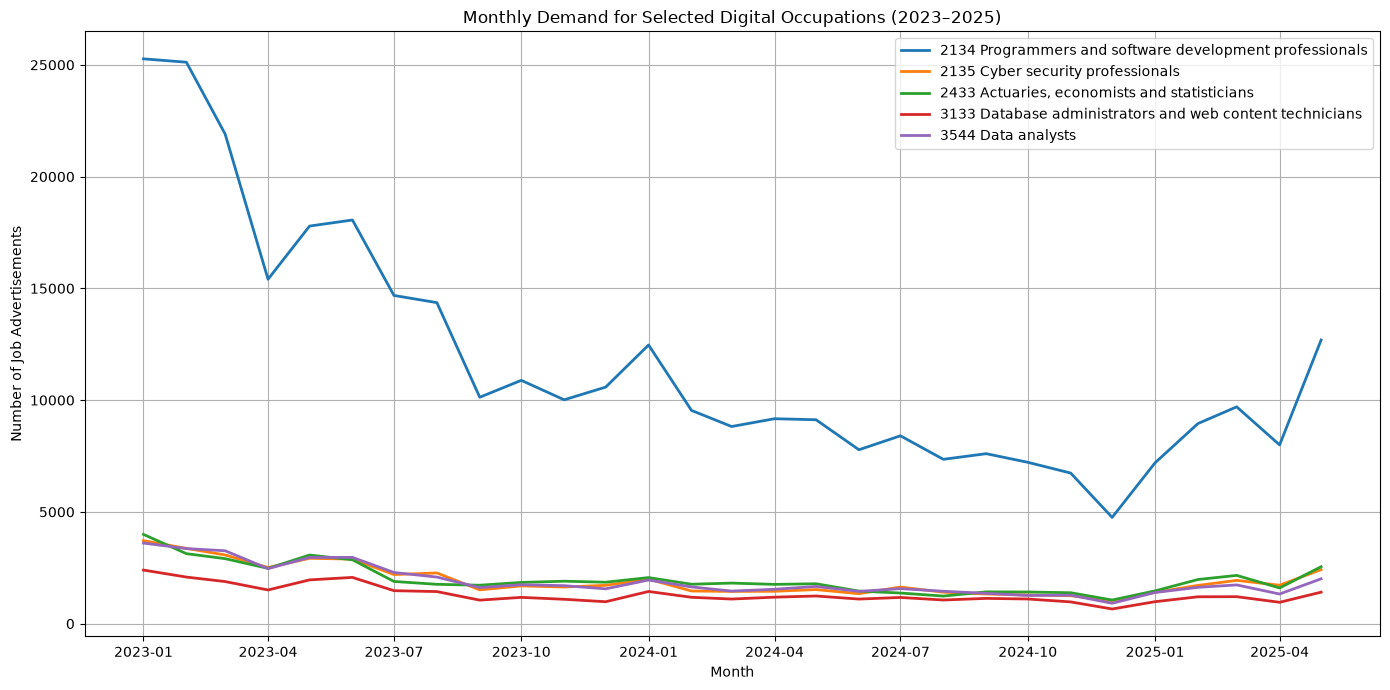

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

occupations = [
    "2134 Programmers and software development professionals",
    "2135 Cyber security professionals",
    "2433 Actuaries, economists and statisticians",
    "3133 Database administrators and web content technicians",
    "3544 Data analysts"
]

for col in occupations:
    plt.plot(df["Month"], df[col], linewidth=2, label=col)

plt.title("Monthly Demand for Selected Digital Occupations (2023–2025)")
plt.xlabel("Month")
plt.ylabel("Number of Job Advertisements")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
plt.savefig(
    r"D:\MScProjects\labour-market-intelligence\results\monthly_demand_trend.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [12]:
corr = df.drop(columns=["Month","Year","Month_Name"]).corr()

corr

,2134 Programmers and software development professionals,2135 Cyber security professionals,"2433 Actuaries, economists and statisticians",3133 Database administrators and web content technicians,3544 Data analysts
2134 Programmers and software development professionals,1.000000,0.974569,0.928160,0.951599,0.986018
2135 Cyber security professionals,0.974569,1.000000,0.951328,0.954844,0.978162
"2433 Actuaries, economists and statisticians",0.928160,0.951328,1.000000,0.932713,0.940055
3133 Database administrators and web content technicians,0.951599,0.954844,0.932713,1.000000,0.974971
3544 Data analysts,0.986018,0.978162,0.940055,0.974971,1.000000


In [13]:
corr.to_csv(
r"D:\MScProjects\labour-market-intelligence\data\processed\occupation_correlation.csv"
)

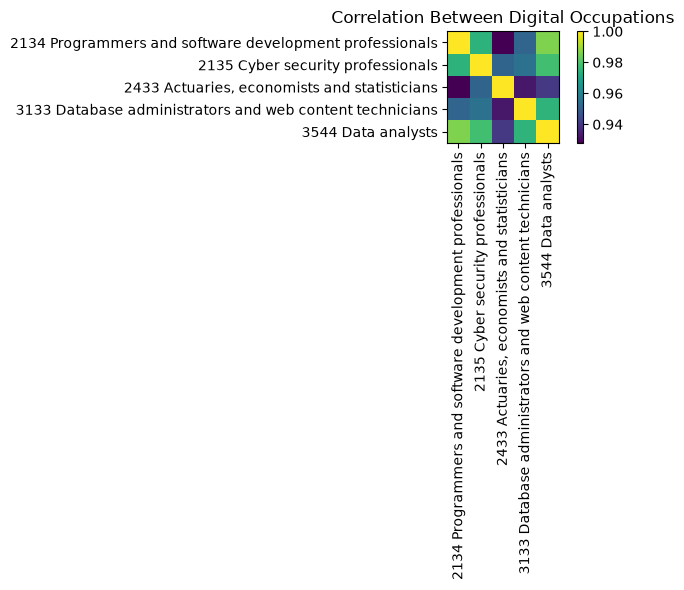

In [14]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Between Digital Occupations")

plt.tight_layout()

plt.show()

In [15]:
plt.savefig(
r"D:\MScProjects\labour-market-intelligence\results\correlation_heatmap.png",
dpi=300
)

<Figure size 640x480 with 0 Axes>

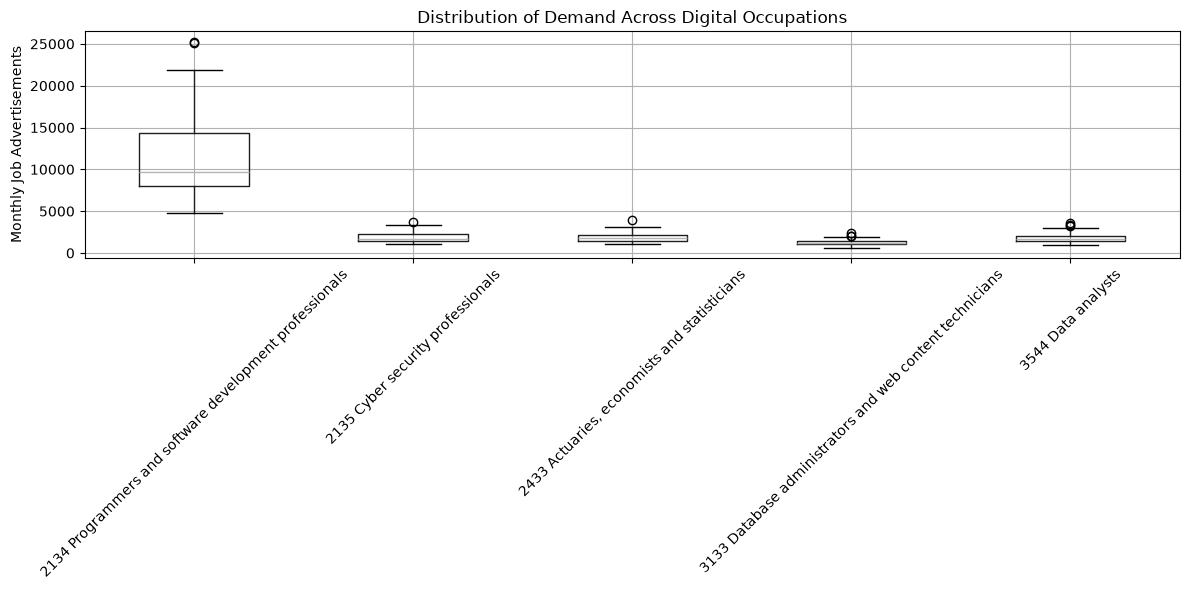

In [16]:
plt.figure(figsize=(12,6))

df.drop(columns=["Month","Year","Month_Name"]).boxplot()

plt.xticks(rotation=45)

plt.ylabel("Monthly Job Advertisements")

plt.title("Distribution of Demand Across Digital Occupations")

plt.tight_layout()

plt.show()

In [17]:
plt.savefig(
r"D:\MScProjects\labour-market-intelligence\results\boxplot.png",
dpi=300
)

<Figure size 640x480 with 0 Axes>

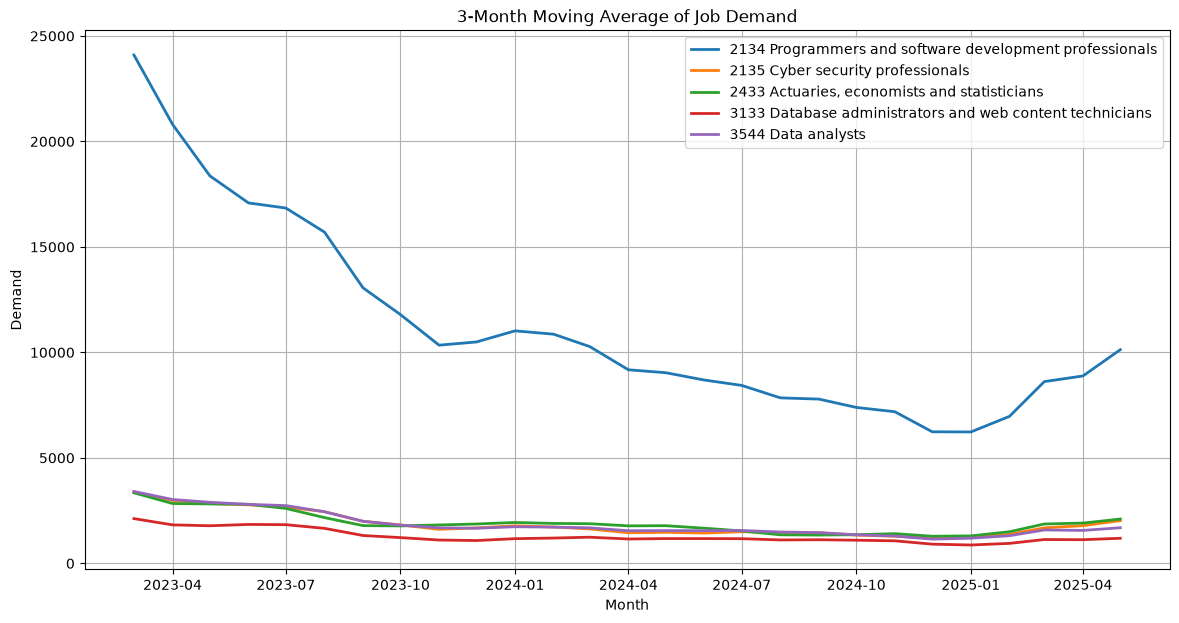

In [18]:
rolling = df.copy()

for col in occupations:
    rolling[col] = rolling[col].rolling(3).mean()

plt.figure(figsize=(14,7))

for col in occupations:
    plt.plot(
        rolling["Month"],
        rolling[col],
        linewidth=2,
        label=col
    )

plt.title("3-Month Moving Average of Job Demand")

plt.xlabel("Month")

plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
plt.savefig(
r"D:\MScProjects\labour-market-intelligence\results\moving_average.png",
dpi=300
)

<Figure size 640x480 with 0 Axes>

In [20]:
summary = df.describe().T

summary

,count,mean,min,25%,50%,75%,max,std
Month,29,2024-03-01 13:14:28.965517,2023-01-01 00:00:00,2023-08-01 00:00:00,2024-03-01 00:00:00,2024-10-01 00:00:00,2025-05-01 00:00:00,NaN
2134 Programmers and software development professionals,29.0,11714.068966,4754.0,7997.0,9700.0,14362.0,25269.0,5380.953918
2135 Cyber security professionals,29.0,1924.827586,1032.0,1442.0,1689.0,2268.0,3712.0,695.986918
"2433 Actuaries, economists and statisticians",29.0,1988.37931,1057.0,1467.0,1815.0,2159.0,3993.0,670.117869
3133 Database administrators and web content technicians,29.0,1317.137931,656.0,1090.0,1179.0,1440.0,2397.0,402.368321
3544 Data analysts,29.0,1903.413793,913.0,1449.0,1643.0,2084.0,3606.0,698.518919
Year,29.0,2023.758621,2023.0,2023.0,2024.0,2024.0,2025.0,0.739458


In [21]:
summary.to_csv(
r"D:\MScProjects\labour-market-intelligence\data\processed\summary_statistics.csv"
)

In [2]:
import pandas as pd

dfs = {}

# Make a fixed copy before iterating
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dfs[name] = obj.shape

print("DataFrames currently in memory:\n")

for name, shape in sorted(dfs.items()):
    print(f"{name:35s} {shape}")

DataFrames currently in memory:

